# Modelo de Classificação para diagnóstico de diabetes em homens e mulheres, baseado em conjuntos de Árvores de Decisão (Gradient Boosting)
---

O dataset utilizado para este projeto é [Diabetes prediction dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset/data), disponível na plataforma Kaggle

## A) Manipulação dos Dados, Análises
---

### 1. Importação das bibliotecas
---

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


### 2. Criação do DataFrame, utilizando o dataset selecionado
---

In [101]:
df = pd.read_csv('diabetes_prediction_dataset.csv', sep=',')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [102]:
df.shape

(100000, 9)

### 3. Manipulação dos Dados
---

#### 3.1. Conferência de ocorrênca ou ausência de valores nulos
---

In [103]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

#### 3.2. Tradução dos nomes das colunas para Português Brasileiro
---

In [104]:
df = df.rename(columns= {'gender':'genero',
                'age':'idade',
                'hypertension':'hipertensao',
                'heart_disease':'doenca_cardiaca',
                'smoking_history':'historico_tabagismo',
                'bmi':'imc',
                'HbA1c_level':'hemoglobina_glicada',
                'blood_glucose_level':'taxa_glicemia',
                'diabetes':'diagnostico_diabetes'})

In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   genero                100000 non-null  str    
 1   idade                 100000 non-null  float64
 2   hipertensao           100000 non-null  int64  
 3   doenca_cardiaca       100000 non-null  int64  
 4   historico_tabagismo   100000 non-null  str    
 5   imc                   100000 non-null  float64
 6   hemoglobina_glicada   100000 non-null  float64
 7   taxa_glicemia         100000 non-null  int64  
 8   diagnostico_diabetes  100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 8.0 MB


#### 3.3. Adequação de valores dos atributos genero e historico_tabagismo
---

***Nota:*** `Pesquisar o uso de:` [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder) e [Ordinal Enconding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder|)

Os atributos `genero` e `historico_tabagismo` possuem categorias dentro de seus valores, como Male, Female, Never, Former, entre outros. Isso deve ser tratado para chegar ao modelo, garantindo que processe tudo bem e sua eficiência seja a maior possível.

A abordagem escolhida para fazer isso é o [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder), por poder tratar os atributos categóricos, sem aumentar a dimensionalidade (aumentar o número de atributos), como o One-Hot Encoding faz.

In [106]:
df[['genero', 'historico_tabagismo']].value_counts()

genero  historico_tabagismo
Female  never                  22869
        No Info                19700
Male    No Info                16110
        never                  12223
Female  current                 5058
        former                  4774
Male    former                  4578
        current                 4228
Female  not current             3913
Male    not current             2526
Female  ever                    2238
Male    ever                    1765
Other   not current                8
        No Info                    6
        never                      3
        ever                       1
Name: count, dtype: int64

In [107]:
atr_categoricos = ['genero', 'historico_tabagismo']

# Criação da instância da classe OrdinalEncoder()
encoder = OrdinalEncoder()

# Adequação das categorias de string para float64
df[atr_categoricos] = encoder.fit_transform(df[atr_categoricos])

In [108]:
df[['genero', 'historico_tabagismo']].value_counts()

genero  historico_tabagismo
0.0     4.0                    22869
        0.0                    19700
1.0     0.0                    16110
        4.0                    12223
0.0     1.0                     5058
        3.0                     4774
1.0     3.0                     4578
        1.0                     4228
0.0     5.0                     3913
1.0     5.0                     2526
0.0     2.0                     2238
1.0     2.0                     1765
2.0     5.0                        8
        0.0                        6
        4.0                        3
        2.0                        1
Name: count, dtype: int64

#### 3.4. Adequação da tipagem dos demais atributos
---

Os dados numéricos estavam com  a tipagem padrão de Pandas de int64 e float64. Para atenuar o gasto de memória RAM e aumentar a eficiência dos testes, treino e interação com o modelo, estes dados passarão por *downcasting* (redução de precisão) para int32 ou float32, a depender do atributo e seu papel no dataset. 

Como referência, há a página [Scaling to large datasets](https://pandas.pydata.org/docs/user_guide/scale.html) da documentação de Pandas, onde é dito e exemplificado o uso de RAM da tipagem padrão da biblioteca e como pode ser interessante diminuir o tamanho dos dados

In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   genero                100000 non-null  float64
 1   idade                 100000 non-null  float64
 2   hipertensao           100000 non-null  int64  
 3   doenca_cardiaca       100000 non-null  int64  
 4   historico_tabagismo   100000 non-null  float64
 5   imc                   100000 non-null  float64
 6   hemoglobina_glicada   100000 non-null  float64
 7   taxa_glicemia         100000 non-null  int64  
 8   diagnostico_diabetes  100000 non-null  int64  
dtypes: float64(5), int64(4)
memory usage: 6.9 MB


In [126]:
cols_int = ['hipertensao', 'doenca_cardiaca', 'taxa_glicemia', 'diagnostico_diabetes']
cols_float = ['idade', 'imc', 'hemoglobina_glicada', 'genero', 'historico_tabagismo']

# df
for col in cols_int:
    df[col] = df[col].astype(np.int32)
    print(f'O atributo {col.upper()} de df foi convertida para int32.\n')

for col in cols_float:
    df[col] = df[col].astype(np.float32)
    print(f'O atributo {col.upper()} de df foi convertida para float32.\n')


O atributo HIPERTENSAO de df foi convertida para int32.

O atributo DOENCA_CARDIACA de df foi convertida para int32.

O atributo TAXA_GLICEMIA de df foi convertida para int32.

O atributo DIAGNOSTICO_DIABETES de df foi convertida para int32.

O atributo IDADE de df foi convertida para float32.

O atributo IMC de df foi convertida para float32.

O atributo HEMOGLOBINA_GLICADA de df foi convertida para float32.

O atributo GENERO de df foi convertida para float32.

O atributo HISTORICO_TABAGISMO de df foi convertida para float32.



In [122]:
df.info()

<class 'pandas.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   genero                96146 non-null  float32
 1   idade                 96146 non-null  float32
 2   hipertensao           96146 non-null  int32  
 3   doenca_cardiaca       96146 non-null  int32  
 4   historico_tabagismo   96146 non-null  float32
 5   imc                   96146 non-null  float32
 6   hemoglobina_glicada   96146 non-null  float32
 7   taxa_glicemia         96146 non-null  int32  
 8   diagnostico_diabetes  96146 non-null  int32  
dtypes: float32(5), int32(4)
memory usage: 4.0 MB


#### 3.5. Conferência e exclusão de Duplicatas
---

A presença de registros duplicados pode introduzir vieses indesejados no modelo, levando-o ao `overfitting`, quando o algoritmo memoriza amostras específicas em vez de aprender padrões generalizáveis.

Abaixo, é feito o cálculo para descobrir o número de registros duplicados, e qual a porcentagem que eles representam em relação ao todo.

In [112]:
total_duplicadas = df.duplicated().sum()
total_linhas = df.shape[0]

print(f'O total de registros duplicados é de {total_duplicadas} em um total de {total_linhas}. Isto corresponde a {((total_duplicadas / total_linhas) * 100):.2f}% do total')

O total de registros duplicados é de 3854 em um total de 100000. Isto corresponde a 3.85% do total


Essas duplicatas serão excluídas deixando apenas os registros originais.

In [113]:
# O argumento 'first' do parâmetro keep prevê que a primeira ocorrência da duplicata será mantida e as demais ocorrências serão apagadas
df = df.drop_duplicates(keep='first')

In [114]:
df.info()

<class 'pandas.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   genero                96146 non-null  float32
 1   idade                 96146 non-null  float32
 2   hipertensao           96146 non-null  int32  
 3   doenca_cardiaca       96146 non-null  int32  
 4   historico_tabagismo   96146 non-null  float32
 5   imc                   96146 non-null  float32
 6   hemoglobina_glicada   96146 non-null  float32
 7   taxa_glicemia         96146 non-null  int32  
 8   diagnostico_diabetes  96146 non-null  int32  
dtypes: float32(5), int32(4)
memory usage: 4.0 MB


#### 3.6. Conferência de valores únicos
---

O método df.nunique mostra a quantidade de valores distintos (únicos) em cada atributo. Com ele, é possível perceber categorias e presença de faixas de valores nas colunas. 

É possível perceber de imediato, os atributos que, apesar de terem a tipagem int64 no dataset original, também poderiam ser booleanos, sendo estes `hipertensao`, `doenca_cardiaca` e `diagnostico_diabetes`. Estes são justamente os que perguntam se o indivíduo é diagnosticado ou não com estas condições.

Indica-se, também os atributos categóricos, `genero` e `historico_tabagismo`, com 3 e 6 valores, respectivamente, que foram convertidos na seção 3.3 do item A).

`hemoglobina_glicada` e `taxa_glicemia` são atributos relativos à saúde e estilo de vida, já que estão ligados a glicose no sangue dos indivíduos. Possuem 18 valores únicos. É uma grande quantidade de valores, para se afirmar que são categóricas, mas sugere a possibilidade de estes dados terem sido coletados de indivíduos de uma mesma região ou, talvez, de realidades sociais, de vida e consumo similares, mesmo que de localizações distantes, por terem vários valores em comum entre os registros.

Para `idade` há 102 valores distintos, indicando a possibilidade de haver uma grande variedade etária entre os indivíduos. Por último, o `imc` é o que mais varia, com 4247 valores únicos. Estes são os atributos de maior granularidade, detalhamento, por possuírem a maior quantidade de registros.

In [115]:
df.nunique()

genero                     3
idade                    102
hipertensao                2
doenca_cardiaca            2
historico_tabagismo        6
imc                     4247
hemoglobina_glicada       18
taxa_glicemia             18
diagnostico_diabetes       2
dtype: int64

### 4. Análise Exploratória dos Dados
---

Serão apresentados, para maior conhecimento dos dados em cada atributo: 
1. Cálculos de `Medidas de Tendência Central` para maior entendimento dos dados contidos em cada atributo;
2. `Histogramas` para comparação entre a `Curva Normal` e `KDE (Estimativa de Densidade por Kernel)`, com o intuito de ter o entendimento da evolução dos dados;
3. `Boxplot`para detecção de outliers. 

#### 4.1. Cálculos de Medidas de Tendência Central 
---

Serão expostos os dados pelo método `.describe()`, mas todas os atributos terão um texto, escrito com a função `imprimir_descricao()` mostrados à parte, com informações extras.

In [116]:
df.describe()

,genero,idade,hipertensao,doenca_cardiaca,historico_tabagismo,imc,hemoglobina_glicada,taxa_glicemia,diagnostico_diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,0.416065,41.794323,0.077601,0.040803,2.231159,27.321461,5.532609,138.218231,0.088220
std,0.493287,22.462948,0.267544,0.197833,1.879963,6.767715,1.073232,40.909771,0.283616
min,0.000000,0.080000,0.000000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,0.000000,43.000000,0.000000,0.000000,3.000000,27.320000,5.800000,140.000000,0.000000
75%,1.000000,59.000000,0.000000,0.000000,4.000000,29.860001,6.200000,159.000000,0.000000
max,2.000000,80.000000,1.000000,1.000000,5.000000,95.690002,9.000000,300.000000,1.000000


In [117]:
def imprimir_descricao(nome_col):
    '''Função que mostra e explica as Medidas de Tendência Central de cada atributo'''
    try:
        contagem = df[nome_col].count()
        nulas = df[nome_col].isna().sum()
        duplicadas = df[nome_col].size - df[nome_col].nunique()
        valores_unicos = df[nome_col].nunique()
        media = df[nome_col].mean()
        valor_minimo = df[nome_col].min()
        valor_maximo = df[nome_col].max()
        desvio_padrao = df[nome_col].std()
        quartil_25 = df[nome_col].quantile(0.25)
        quartil_50 = df[nome_col].quantile(0.50)
        quartil_75 = df[nome_col].quantile(0.75)
        moda = df[nome_col].mode()[0]

        print(f'\n\n Análise das Medidas de Tendência Central do atributo {nome_col}:')
        print(f'\n - No total, há {contagem} células e destas, {nulas} são nulas, {duplicadas} estão repetidas e o total de valores únicos são {valores_unicos};')
        print(f'\n - A média aritmética de seus valores é, aproximadamente, {media:.2f};')
        print(f'\n - A moda é, aproximadamente, {moda:.2f};')
        print(f'\n - O valor mínimo registrado é {valor_minimo:2f}, e o máximo, {valor_maximo:2f};')
        print(f'\n - O desvio padrão é, aproximadamente, {desvio_padrao:.2f}. Isto significa que os valores tendem a ocilar entre + {desvio_padrao:.2f} e - {desvio_padrao:.2f} em relação a média aritmética,  de valor {media:.2f};')
        print(f'\n - O valor do quartil de 25% é {quartil_25:2f}. Este ponto mostra onde chega ao certo em 25% dos valores do atributo;')
        print(f'\n - O valor do quartil de 50% é {quartil_50:2f}. Este ponto mostra a mediana dos valores da coluna;')
        print(f'\n - O valor do quartil de 75% é {quartil_75:2f}. Este ponto mostra onde chega ao certo em 25% dos valores do atributo.\n\n')
    except ValueError:
        print('Erro de valor. Certifique de a coluna ter valor numérico')
    except Exception as e:
        print(f'Ocorreu esse erro: {e}')

In [118]:
for col in df.columns:
    print(f'\n---\nAtributo {col.upper()}:\n\n')
    imprimir_descricao(col)
    


---
Atributo GENERO:




 Análise das Medidas de Tendência Central do atributo genero:

 - No total, há 96146 células e destas, 0 são nulas, 96143 estão repetidas e o total de valores únicos são 3;

 - A média aritmética de seus valores é, aproximadamente, 0.42;

 - A moda é, aproximadamente, 0.00;

 - O valor mínimo registrado é 0.000000, e o máximo, 2.000000;

 - O desvio padrão é, aproximadamente, 0.49. Isto significa que os valores tendem a ocilar entre + 0.49 e - 0.49 em relação a média aritmética,  de valor 0.42;

 - O valor do quartil de 25% é 0.000000. Este ponto mostra onde chega ao certo em 25% dos valores do atributo;

 - O valor do quartil de 50% é 0.000000. Este ponto mostra a mediana dos valores da coluna;

 - O valor do quartil de 75% é 1.000000. Este ponto mostra onde chega ao certo em 25% dos valores do atributo.



---
Atributo IDADE:




 Análise das Medidas de Tendência Central do atributo idade:

 - No total, há 96146 células e destas, 0 são nulas, 96044 estão rep

#### 4.2. Visualização dos dados de cada atributo, usando Histograma, Curva Normal e KDE
---

Esou usando como referência o texto [Distribuição Normal (Gaussiana)](https://www.inf.ufsc.br/~andre.zibetti/probabilidade/normal.html) da UFSC, as páginas [seaborn.histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn-histplot) da documentação oficial de Seaborn, [Normal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.Normal.html), da documentação oficial de SciPy e o vídeo [Histograma e ajuste de gaussiana - Python - Ajuste_gaussiana](https://www.youtube.com/watch?v=bND2aSsMh-4) do canal [PIBIC Henrique Martins Ferreira](https://www.youtube.com/@pibichenriquemartinsferrei3222) do YouTube

In [159]:
def gerar_histplot_curva_nao_categorica(nome_col, kde=True, stat='density', cor_barra='blue', cor_linha = 'skyblue', espessura_linha=2, rotulo='KDE'):
    '''Função que gera histplot com a Curva Normal e KDE (Estimativa de Densidade por Kernel) para ser usada com atributos não categoricos'''
    try:    
        # Define o tamanho da figura
        plt.figure(figsize=(10,10))
    
        # Cria o gráfico de histograma e a linha KDE
        grafico = sns.histplot(df[nome_col], kde=kde, stat=stat, color=cor_barra, line_kws={'color': cor_linha, 'linewidth':espessura_linha}, label='KDE')

        plt.show()
        return grafico

    except ValueError:
        print('Erro de valor. Confira a tipagem dos dados enviados.')
        return None

    except KeyError:
        print('Coluna não encontrada. Favor digitar uma coluna válida.')
        return None
        
    except Exception as e:
        print(f'Ocorreu o seguinte erro: {e}')
        return None

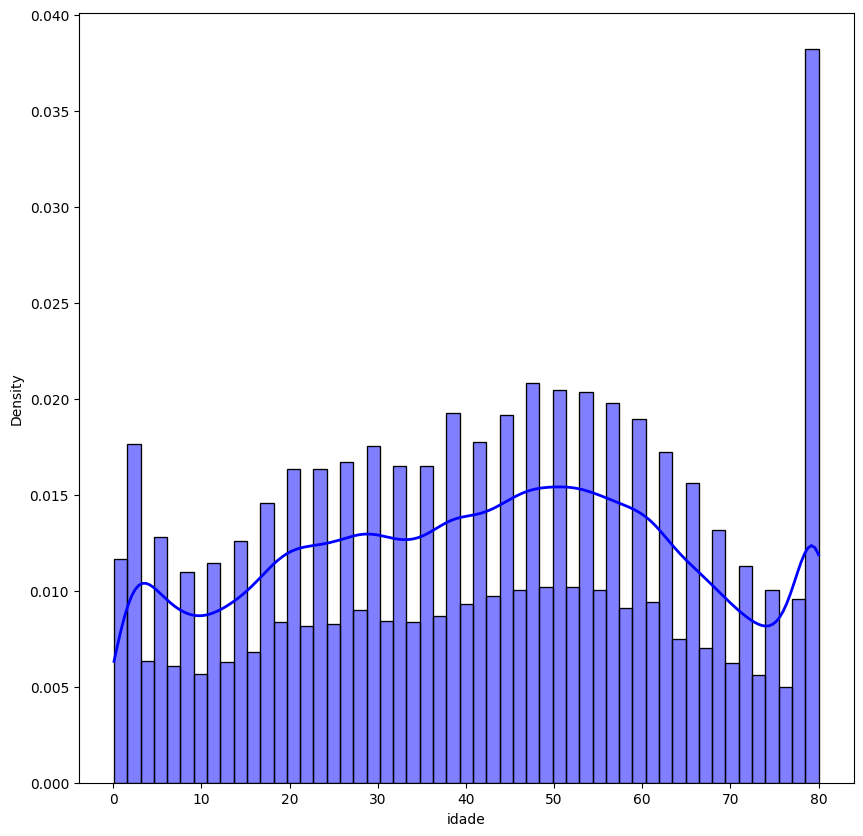

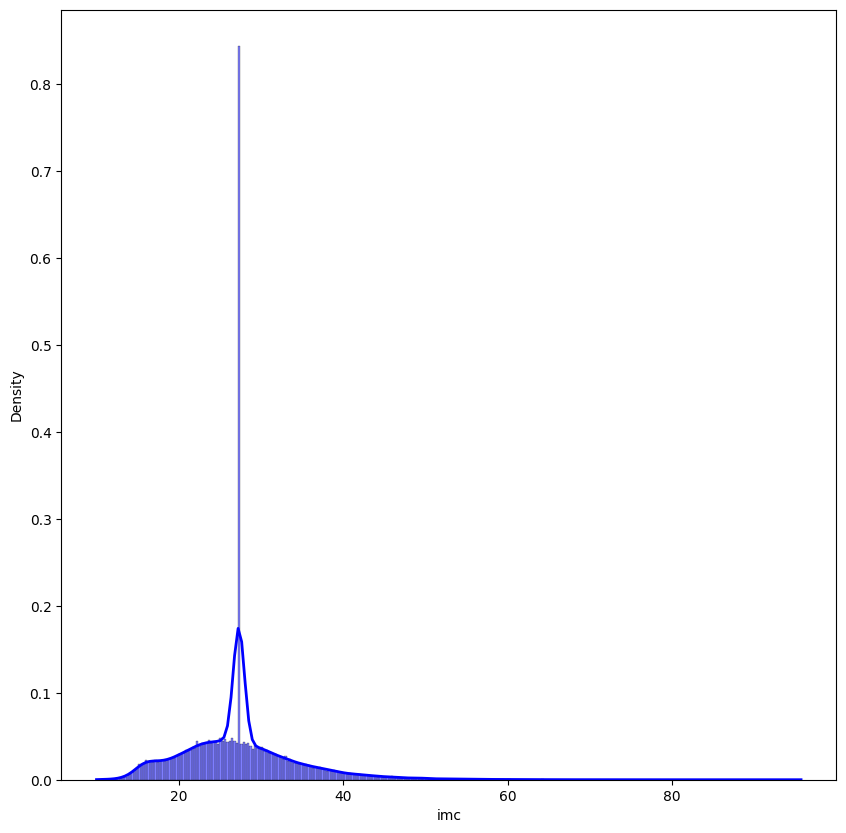

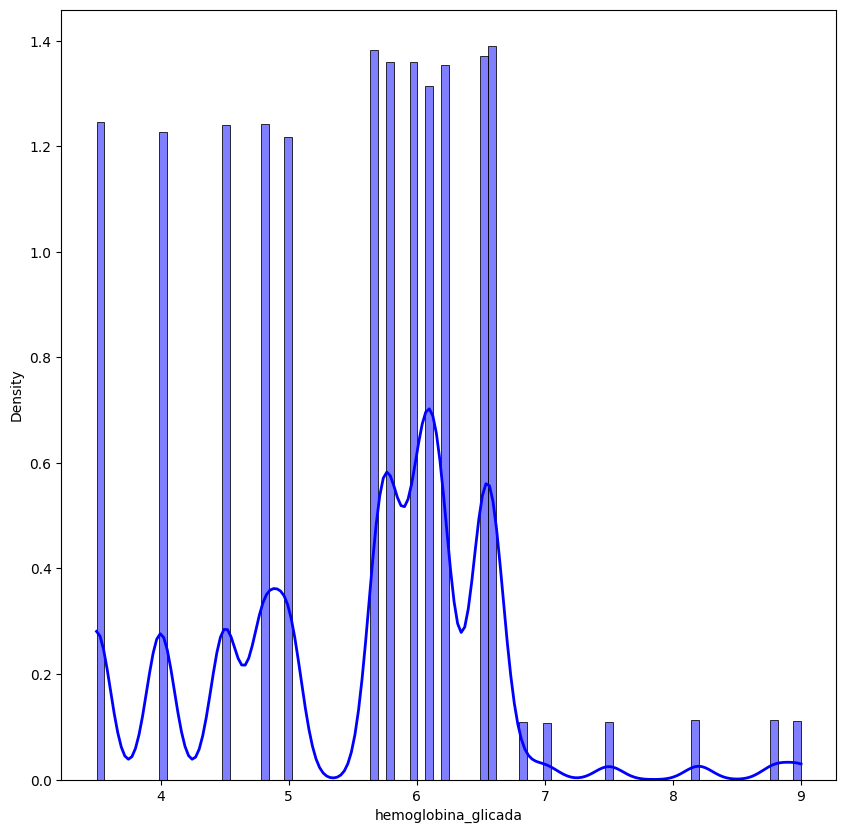

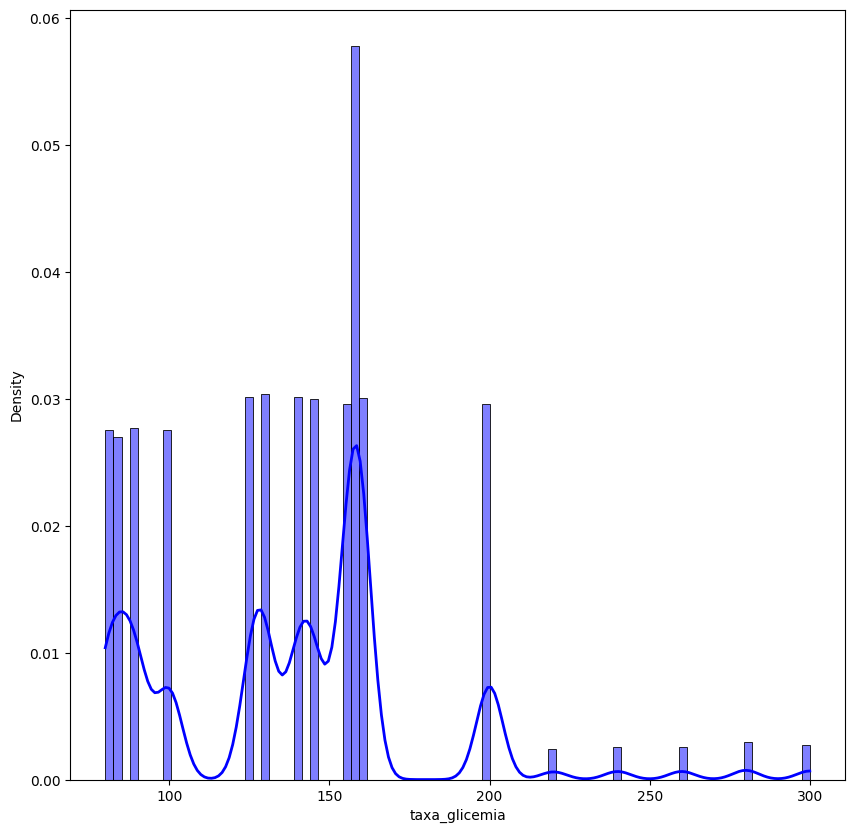

In [160]:
atr_nao_categoricos = df.columns.drop(['genero', 'historico_tabagismo', 'diagnostico_diabetes', 'doenca_cardiaca', 'hipertensao'])

for col in atr_nao_categoricos:
    print(f'Atributo {col}:')
    gerar_histplot_curva_nao_categorica(col)

#### 4.4. Conferência de Balanceamento dos dados do atributo diagnostico_diabetes 
---

O atributo `diagnostico_diabetes` contém os resultados. Nele são trazidos os valores `0` para diagnóstico negativo para diabetes e `1` para positivo.

Caso esta coluna esteja desbalanceada, há a possibilidade de o modelo tender a indicar o resultado que mais ocorreu, mais vezes, podendo trazer enviesamento à predição.

**Cálculo de Balanceamento:**

In [ ]:
num_negativo = (df['diagnostico_diabetes'] == 0).sum()
num_positivo = (df['diagnostico_diabetes'] == 1).sum()
num_total = df['diagnostico_diabetes'].count()
percentual_negativo = ((num_negativo/num_total) * 100)
percentual_positivo = ((num_positivo/num_total) * 100)

print(f'O número total de registros para o atributo diagnostico_diabetes é {num_total}, sendo que {num_negativo} são negativos e {num_positivo} são positivos.\n')
print(f'Dessa forma, temos que o total de casos negativos representa, aproximadamente, {percentual_negativo:.2f}% do total e o total de casos positivos, {percentual_positivo:.2f}%.\n')
print(f'A diferença entre o percentual total de ambos valores é de {(percentual_negativo - percentual_positivo):.2f}%\n')
print(f'A diferença entre os valores totais é {num_negativo - num_positivo}')

A alta diferença percentual entre os diagnósticos `negativo` e `positivo` mostra um grande desbalanço de desvalores do atributo. 

Evidencia de maneira clara, que quando este for dividido em `y_treino` e `y_teste` pela função `train_test_split()` de Scikit-Learn para o treino e teste do modelo, haverá a necessiadade de ser feito um balanceamento com a biblioteca imblearn.  

#### 4.5. Criação, visualização e análise da Matriz de Correlação de Pearson
---

A `Matriz de Correlação de Pearson` é extremamente importante para o conhecimento e entendimento dos dados, mas é de difícil visualização, se analisada em formato de tabela.

Nela, são dispostos números no intervalo entre `-1` e `1`, apresentando o tipo de correlação entre os atributos. Entre `-1` e `0`, há a correlação negativa, onde se um atributo aumenta o outro diminui, e vice-versa; `0`, demonstra neutralidade entre atributos; entre `0`e `1`, há a correlação positiva, onde no caso de um aumentar, o outro também aumenta.

O heatmap (mapa de calor) facilita muito a visualização da correlação entre as variáveis e adicionar as annotations (os números presentes em cada quadrado), faz com que fique ainda mais claro, se ao aumentar o valor de uma célula de um registro, o outro correspondente também irá aumentar ou não.

In [ ]:
# Criação da Matriz de Correlação
matriz_corr = df.corr()
matriz_corr

In [ ]:
# Visualização da Matriz de Correlação
plt.figure(figsize=(16,16))
sns.heatmap(matriz_corr, annot=True)
plt.show()

**Inferências extraídas da Matriz de Correlação:**

- Atributo Target: diagnostico_diabetes.
- Atributo Feature: genero, idade, hipertensao, doenca_cardiaca, historico_tabagismo, imc, hemoglobina_glicada, taxa_glicemia.

| Feature | Correlação em relação a Target |
| :---: | :---: |
| `genero` | 0.037 |
| `idade` | 0.26 |
| `hipertensao` | 0.2 |
| `doenca_cardiaca` | 0.17 |
| `historico_tabagismo` | 0.094 |
| `imc` | 0.21 |
| `hemoglobina_glicada` | 0.4 |
| `taxa_glicemia` | 0.42 |

***Conclusão***:

Nota-se, de acordo com a base de dados, não haver nenhuma correlação negativa com a variável alvo, de modo que todas as features estão ligadas à positividade da diabetes. 

Features como `genero` e `historico_tabagismo`, apresentando os valores de `0.037` e `0.094`, respectivamente são quase neutras em relação ao diagnóstico da doença. Contudo, são atributos categóricos e estes resultados, podem sugerir que os resultados de diagnóstico estão bem distribuídos entre as suas categorias. 

O aumento das seguintes features tende a ser o **mais preponderante** para que o resultado seja positivo: `taxa_glicemia` (0.42), `hemoglobina_glicada` (0.4), `idade` (0.26), `imc` (0.21) e `hipertensao` (0.2).

Por outro  lado, o aumento dessa feature, tende a ser **menos preponderante** para que o paciente tenha resultado positivo para diabetes: `doenca_cardíaca` (0.17).

## B) Criação, treinamento e teste do Modelo de Classificação de Aprendizado Supervisionado

### 1. Divisão das variáveis em Target e Features
---

In [ ]:
X = df.drop(columns=['diagnostico_diabetes']) # Features, o input feito pelo usuário 
y = df['diagnostico_diabetes'] # Target, o output (saída) do modelo

### 2. Divisão do dataset para treino e testes usando a função train_test_split do SciKit-Learn
---

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42) 

**Explicando os parâmetros da função train_test_split:**
- x é a variável que contém as features.
- y é a variável que contém o target.
- test_size, com o valor 0,2 prevê que 80% dos dados do dataset serão usados para treino e 20%, para testes.
- random_state=42 garante que a divisão dos dados seja sempre a mesma em cada execução, permitindo a reprodutibilidade dos resultados.

In [ ]:
df.shape

In [ ]:
X_treino.shape

In [ ]:
X_teste.shape

In [ ]:
y_treino.shape

In [ ]:
y_teste.shape

### 3. Balanceamento dos valores do df com SMOTE-NC
---

#### 3.1. Conferência do balanceamento dos valores do target
---

In [ ]:
diag_positivo = y_treino.value_counts()[1]
diag_negativo = y_treino.value_counts()[0]
percentual_positivo = (diag_positivo/y_treino.count()) * 100
percentual_negativo = (diag_negativo/y_treino.count()) * 100

print(f'\nO valor total de resultados positivos é de {diag_positivo} e o de negativos, {diag_negativo}.\n\nDessa forma, os percentuais são:\n - Positivos: {percentual_positivo:.2f}%;\n - Negativos: {percentual_negativo:.2f}%.')
print(f'\nA diferença entre os percentuais é de {(percentual_negativo - percentual_positivo):.2f}%.') 

Com a diferença entre percentuais de diagnósticos positivos e negativos vista, percebe-se um grande desbalanceamento dos valores do target.

Isso precisa ser tratado para garantir uma melhor eficiência e confiabilidade do modelo. Para tal, será usada a classe SMOTE-NC da biblioteca Imbalanced Learn (imblearn).

#### 3.2. Implementação do SMOTE
---

Os dados foram mostrados como significativamente desbalanceados. 

O atributo `diagnostico_diabetes` mostrava no entorno de 90% dos casos como negativos. 

O grande problema que isso pode gerar é de o modelo começar a "pressupor" que os resultados serão negativos de forma errônea, levando a um aumento de `Falsos Negativos`. Este é o erro mais sensível, pois em um cenário real, poderia levar a um atraso do tratamento de um paciente, por ele não saber de sua condição.

Usei como referência a página do [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) da documentação oficial da Imbalanced Learn (imblearn).

In [ ]:
sm = SMOTE(random_state=42)

X_treino_balanceado, y_treino_balanceado = sm.fit_resample(X_treino, y_treino) 

print(f'Antes do SMOTE: {y_treino.value_counts()}\nDepois do SMOTE: {y_treino_balanceado.value_counts()}')

### 4. Treino do modelo de Classificação usando XGBoost e Scikit-Learn
---

In [ ]:
xgb_classifier = XGBClassifier(objective='binary:logistic', eval_metric='error', enable_categorical = True, learning_rate=0.5, max_depth=3, n_estimators=120, scale_pos_weight=3)
xgb_classifier.fit(X_treino, y_treino) # Treino do Modelo

**Explicando os parâmetros utilizados em XGBClassifier:**

- objective='binary:logistic' → Define que o problema é de classificação binária, ou seja, prever duas classes (True/False, 0/1)
  
- eval_metric='error' → Métrica de avaliação usada durante o treino. Aqui, “error” significa a taxa de erro de classificação (proporção de previsões incorretas)

- learning_rate=0.3 → Também chamado de eta. Controla o tamanho do passo em cada atualização. Valores menores tornam o aprendizado mais lento, mas podem melhorar a generalização

- max_depth=1 → Profundidade máxima das árvores de decisão. Árvores rasas (como 1) reduzem complexidade e ajudam a evitar overfitting (decorar os dados), mas podem limitar a capacidade de capturar relações complexas. Havia atribuído 1, mas aumentei poiss uma árvore seria simples para pegar sinais mais sutis

- n_estimators=100 → Número de árvores (ou rodadas de boosting) que serão treinadas. Mais árvores aumentam a capacidade do modelo, mas também o risco de overfitting se não houver regularização. Havia atribuído 10, mas aumentei o número de árvores para aumentar precisão

- scale_pos_weight=2 → Equilibra os pesos positivos e negativos. Adicionei posteriormente, pois o modelo estava com dificuldade de atribuir o positivo a diabetes 


#### 4.1. Verificação da acurácia do modelo de Classificação
---

In [ ]:
resultado_teste = xgb_classifier.score(X_teste, y_teste)
print(f'O percentual de acurácia atual do modelo é de aproximadamente {(resultado_teste * 100):.2f}%')

#### 4.2. Realização de predições com os dados de teste
---

A referência utilizada é a página [Python API Reference](https://xgboost.readthedocs.io/en/latest/python/python_api.html) da documentação oficial do XGBoost

In [ ]:
y_probabilidade = xgb_classifier.predict_proba(X_teste)
y_probabilidade

In [ ]:
# y_predicao = xgb_classifier.predict(X_teste)
# y_predicao

In [ ]:
y_probabilidade.shape

In [ ]:
type(y_probabilidade)

In [ ]:
df.info()

No teste de predição com os valores separados para isso das features, haviam 81 mulheres com resultado negativo para diabetes e 73 com resultado positivo.

### 5. Geração do Relatório de Classificação e Matriz de Confusão, para o modelo como o método `.predict()`
---

***NOTA:*** `REVER`

#### 5.1. Geração do Relatório de Classificação
---

***Nota:*** `Explicar o uso da função argmax() de Numpy`

In [ ]:
y_predicao = np.argmax(y_probabilidade, axis=1)
print(classification_report(y_teste, y_predicao))

**Explicação sobre possíveis resultados:**

- `TP (True Positive)`: modelo previu "positivo" e realmente era positivo.
    Exemplo: modelo disse que o paciente tem a doença, e essa é a realidade.

- `FP (False Positive)`: modelo previu "positivo", mas na realidade era negativo.
    Exemplo: modelo disse que o paciente tem a doença, mas ele não a tem (falso alarme).

- `FN (False Negative)`: modelo previu "negativo", mas na realidade era positivo.
    Exemplo: modelo disse que o paciente não tem a doença, mas ele a tem (erro crítico).

- `TN (True Negative)`: modelo previu "negativo" e realmente era negativo.
    Exemplo: modelo disse que o paciente não tem a doença, e essa é a realidade.

**Explicação do Relatório de Classificação:**

- `Precision`:  confiabilidade do modelo para cada classe. Dessa forma, o modelo acerta 98% das vezes em que inferir que é negativo e 78% das vezes que inferir ser positivo. É a razão TP/(TP+FP)
- `Recall`: conhecido como Taxa de Detecção. Faz com que o modelo consiga identificar mais instâncias de classes de interesse. No contexto, faz com que o modelo consiga enxergar mais mulheres sem deixá-las sem um diagnóstico. É a razão TP/(TP+FN)
- `F1-Score`: média harmônica entre Precisão e Recall. Promove o equilíbrio entre ambas métricas. Atinge seu melhor valor em 1 e o pior valor em 0.
- `Support`: suporte. Indica a quantidade real de cada classe. No caso, foram 106 para negativo e 48 para positivo.
- `Accuracy`: acurácia. Representa o percentual total de acertos.
- `Macro AVG`: média aritmética entre as classes.
- `Weighted AVG`: média ponderada entre as classes.

**Análise:**

Para o modelo, todas as características descritas no Relatório de Classificação são muito importantes. Contudo, o Recall é uma característica que se destaca para o contexto de atendimento ao paciente e diagnóstico, já que trabalhá-lo e aprimorá-lo, garantem que o modelo consiga abranger mais e diagnosticar mais mulheres em relação ao diabetes. Por isso, é importante mantê-la mais aprimorada e equilibrada possível. 

#### 5.2. Geração da Matriz de Confusão
---

***NOTA:*** `CONSIDERAR FAZER OUTRA ANÁLISE, ALÉM DA QUE JÁ FOI FEITA`

A Matriz de Confusão indica o desempenho do modelo que usa o método `.predict()`, mostrando o número de resultados  Verdadeiros Negativos e Positivos, e também, Falsos Negativos e Positivos

In [ ]:
matriz_confusao = confusion_matrix(y_teste, y_predicao)
sns.heatmap(matriz_confusao, annot=True, fmt='d')

**Cálculos**

In [ ]:
matriz_confusao

In [ ]:
(tn, fp), (fn, tp) = matriz_confusao
total = (tn+fn+tp+fp)

In [ ]:
def calcular_percentual(var, total):
    percentual = (((var)/(total))*100)
    return f'{percentual:.2f}'

In [ ]:
print(f'O total de predições de teste foi {total}.')
print(f'\n - Verdadeiro Negativo (TN): Predição correta de ausência da patologia. Há {tn} pacientes que o modelo apontou como resultado negativo, corretamente.')
print(f'\n - Falso Negativo (FN): Predição incorreta de ausência da patologia. Há {fn} pacientes em que o modelo apontou como resultado negativo para diabetes, erroneamente. Maior risco clínico, pois provavelmente eles correm o risco de não buscar tratamento, por não acreditar não ser necessário.')
print(f'\n - Verdadeiro Positivo (TP): Predição correta de presença da patologia. Há {tn} pacientes em que o modelo apontou como resultado positivo, corretamente.')
print(f'\n - Falso Positivo (FP): Predição incorreta de presença da patologia. Há {fp} pacientes em que o modelo apontou como resultado positivo, erroneamente.')
print(f'\n\nResultados:')
print(f'\n - A quantidade de vezes que o modelo acertou é expressa por TN + TP e é igual a {(tn + tp)}, de um total de {total}. Isto corresponde a, aproximadamente, {(((tn + tp) / total) * 100):.2f}% do total.')
print(f'\n - A quantidade de vezes que o modelo errou é expressa por FN + FP e é igual a {(fn + fp)}, de um total de {total}. Isto corresponde a, aproximadamente, {(((fn + fp) / total) * 100):.2f}% do total.\n\n')

In [ ]:
print(f'Número TN: {tn}, percentual: {(calcular_percentual(tn, total))}%')
print(f'Número TP: {tp}, percentual: {calcular_percentual(tp, total)}%')
print(f'Número FN: {fn}, percentual: {calcular_percentual(fn, total)}%')
print(f'Número FP: {fp}, percentual: {calcular_percentual(fp, total)}%')

#### 5.2. Criação e Análise da Curva ROC AUC para o modelo que usa o método `.predict_proba()`
---

### 7. Visualização dos atributos de maior relevância para o diagnóstico

In [ ]:
# Determinar as features de X_treino
relevancia_features = xgb_classifier.feature_importances_
cols_feature_treino = X_treino.columns

# Criação do df_relevancia para facilitar a criação do gráfico de barras
df_relevancia = pd.DataFrame({'Feature':cols_feature_treino, 'Relevância':relevancia_features})
df_relevancia = df_relevancia.sort_values(by='Relevância', ascending=False) # Organiza as barras à partir dos valores de relevância, do maior para o menor

# Criação do gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Relevância', y='Feature', data=df_relevancia, palette='viridis', hue='Feature')

# Customização do gráfico
plt.title('Atributos mais relevantes para o Diagnóstico de Diabetes, do maior para o menor', fontsize=14)
plt.xlabel('Nível de Relevância', fontsize=12)
plt.ylabel('Atributos', fontsize=12)
plt.show()

O gráfico mostra o quanto `taxa_glicemia` e, principalmente, `hemoglobina_glicada` são relevantes para o Diagnóstico de Diabetes, de acordo com a base de dados utilizada e o atributo `.feature_importances_` da classe `XGBClassifier` de XGBoost. As demais features estão muito abaixo tendo, aparentemente, uma relevância muito menor.

## C) Interação com o modelo
---

### 1. Introdução
---

Desenvolvi um algoritmo para que interações e testes possam ser feitos com o modelo. O objetivo era fazer algo rápido, fácil, prático e dentro no mesmo notebook, para que possa ser feita uma simulação de uso desse modelo. Quis centralizar tudo.

Neste programa, aproveitei para usar de informarções percebidas nas análises descritivas, como a prioridade de features, baseado em= sua correlação com o resultado, visto na visualização da Matriz de Correlação. Como dito, as features de idade, número total de gravidez, níveis de glicose e insulina, IMC e função de hereditariedade da diabetes, são críticas e obrigatórias para o diagnóstico e o usuário não poderá deixar de atribuir valores a elas para concluir o processo de predição. Por outro lado, as features de pressão arterial e espessura da pele se mostraram muito menos importantes e acessórias, tendo ambas o valor de correlação menor que 0.1. Dessa forma, optei por imputar o valor delas, para dar ao usuário a possibilidade de não ser obrigado a ter todos os dados em mãos para poder participar, com alterações de valores menores. Isso se dá por tirar a média aritmética dos valores de cada uma das duas colunas, caso o usuário não tenha esses dados ou não queira incluí-los.

Esse dataset possui oito features, sendo seis obrigatórias e duas acessórias

**Exemplos tirados do DF:**
- Exemplo de perfil que leva a resultado **negativo**:
| Feature | Valor |
| :---: | :---:|
| Idade | 33.0 |
| Número total de gravidez | 9.0 |
| Taxa de glicose | 89.0 |
| Pressão arterial | 62.0 |
| Espessura da pele | 0.0 |
| Nível de insulina | 0.0 |
| IMC | 22.5 |
| Função de Hereditariedade de Diabetes | 0.142 |
|  **Resultado** | **0** |
       

- Exemplo de perfil que leva a resultado **positivo**:
| Feature | Valor |
| :---: | :---:|
| Idade | 37.0 |
| Número total de gravidez | 1.0 |
| Taxa de glicose | 128.0 |
| Pressão arterial | 88.0 |
| Espessura da pele | 39.0 |
| Nível de insulina | 110.0 |
| IMC | 36.5 |
| Função de Hereditariedade de Diabetes | 1.057 |
|**Resultado** | **1** |

### 2. Criação do algoritmo de interação
---

#### 2.1. Desenvolvimento da classe Feature, com um método para determinar e tratar as features obrigatórias e acessórias
---

***NOTA:*** `Rever a lógica, já que as colunas categóricas não tem mais categorias substituídas por int`

In [ ]:
mensagem_obrigatoria = ' Dado obrigatório'
mensagem_acessoria = ' Dado não obrigatório. Para pular, aperte enter sem digitar.'
opcoes_genero = {'Masculino':0,'Feminino':1,'Outro':2}
opcoes_tabagismo = {'Prefiro não Informar':0,'Nunca fumei':1,'Ex-Fumante':2,'Atualmente fumo':3,'Parei de fumar':4,'Já fumei alguma vez':5}
opcoes_binarias = {'Não':0, 'Sim':1}

class Feature:
    '''
    Classe para determiar as features usadas para a predição do modelo de classificação
    '''
    def __init__(self, nome_feature,  mensagem, tipo, valor_min=None, valor_max=None, unidade_medida=None, opcoes=None, obrigatoriedade=True):
        self.nome_feature = nome_feature 
        self.mensagem = mensagem
        self.valor_min = valor_min
        self.valor_max = valor_max
        self.opcoes = opcoes
        self.unidade_medida = unidade_medida
        self.obrigatoriedade = obrigatoriedade
        self.tipo = tipo

    def determinar_tratar_feature(self, df=None, nome_col=None): 
        '''
        Método para determinar e fazer os tratamentos cabíveis às features que não apresentam opções para o usuário, de modo que que possam ser usadas pelo modelo de classificação, mitigando erros por conta do usuário
        '''
        while True:
            try:
                valor_input = input(f'\n - Digite o valor de {self.nome_feature} {self.unidade_medida}.{self.mensagem}\n') 
                
                 # Sai do loop da variável ao retornar o None. É sinalizado abaixo da criação da variável que ao retornar None, dará break no loop principal.
                if valor_input.lower() == 'sair':
                    print("\nEncerrando o sistema de predição. Até logo!\n---")
                    return None 
                    
                # Valor convertido para float. Em caso de ser uma feature acessória, ao apertar enter, o resultado será a média aritmética da respectiva coluna do df
                if valor_input == '':
                    if self.obrigatoriedade == False:
                        media = df[nome_col].mean()
                        print(f'\nUsando a média do sistema, sendo essa, aproximadamente, {media:.2f}\n---')
                        return media
                    else:
                        print('\nEsses dados são obrigatórios para o processo de predição de diagnóstico de diabetes. Sem eles, não será possível chegar a uma conclusão. Favor digite os dados.\n')
                        continue
                             
                if float(valor_input) < self.valor_min or float(valor_input) > self.valor_max:
                    print(f'\nO valor mínimo suportado para {self.nome_feature}, é {self.valor_min} e o valor máximo, {self.valor_max}. Favor inserir dados válidos.\n')
                    continue

                print(f'\nValor digitado: {valor_input}\n---')
                return self.tipo(valor_input)
                                          
            except OverflowError:
                print('\nValor extremamente alto.\n')
                continue
            except ValueError:
                print('\nTipo errado ou dado faltante. Digite letras para nome e números para as demais. Para casas decimais utilize "." ao invés de ",".\n')
                continue
            except ZeroDivisionError:
                print('\nNão existe divisão por zero. Mude o valor do divisor e refaça o cálculo.\n')
                continue
            except Exception as e:
                print(f'\nOcorreu o seguinte erro de processamento: {e}\n')
                continue
                
    def determinar_tratar_features_opcoes(self, mensagem_pergunta):
        '''
        Método para determinar e fazer os tratamentos cabíveis às features que apresentam opções pré-definidas para o usuário, de modo que que possam ser usadas pelo modelo de classificação, mitigando erros por conta do usuário
        '''
        while True:
            try:
                # Mostra as opções disponíveis dinamicamente
                lista_opcoes = ", ".join([f"{val}-{key}" for key, val in self.opcoes.items()])
                valor_input = input(f'\n{mensagem_pergunta} {self.nome_feature} Digite o número correto da opção: \n({lista_opcoes})\n')

                if valor_input == 'sair':
                    print('\nEncerrando o sistema de predição. Até logo!\n---')
                    return None

                if valor_input == '':
                    print('\nEsses dados são obrigatórios para o processo de predição de diagnóstico de diabetes. Sem eles, não será possível chegar a uma conclusão. Favor digite os dados.\n')
                    continue

                if float(valor_input) < self.valor_min or float(valor_input) > self.valor_max:
                    print(f'\nO valor mínimo suportado para {self.nome_feature} é {self.valor_min} e o valor máximo, {self.valor_max}. Favor inserir dados válidos.\n')
                    continue
                    
                num_escolhido = int(valor_input)

                nome_opcao = next((key for key, val in self.opcoes.items() if val == num_escolhido), None)
                
                print(F'\nOpção escolhida: número {valor_input} - {nome_opcao}\n---')
                return self.tipo(valor_input)
            
            except OverflowError:
                print('\nValor extremamente alto.\n')
                continue
            except ValueError:
                print('\nTipo errado ou dado faltante. Digite letras para nome e números para as demais. Para casas decimais utilize "." ao invés de ",".\n')
                continue
            except ZeroDivisionError:
                print('\nNão existe divisão por zero. Mude o valor do divisor e refaça o cálculo.\n')
                continue
            except Exception as e:
                print(f'\nOcorreu o seguinte erro de processamento: {e}\n')
                continue

def criar_nome():
    while True:
        try:
            nome = input('\n - Qual o nome do(a) paciente?\n')
            if nome == 'sair':
                print("\nEncerrando o sistema de predição. Até logo!\n---")
                return None
            elif nome == '':
                print('\nDigite o nome da paciente para prosseguir com o processo.\n')
                continue
            else:
                print(f'\nValor digitado: {nome}\n---')
                return nome
            
        except ValueError:
                print('\nTipo errado ou dado faltante. Digite letras para nome e números para as demais. Para casas decimais utilize "." ao invés de ",".')
                continue
            

#### 2.2. Criação do núcleo da Interação com o modelo
---

In [ ]:
print('\nOlá, seja bem vindo() ao Modelo de Predição Diagnóstica contra a Diabetes.\nPara participar, só é necessário inserir os dados pedidos em cada campo.\n\n')

# Para controlar melhor o While True, colocar um contador indicando quantos pacientes serão atendidos (o número que o usuário quiser).
# Ex.: se ele quiser dois, o loop (processo) será feito duas vezes e encerrará. Se quiser mais, roda de novo a célula.
try:
    total_pacientes = input('\nQuantos pacientes serão atendidos?\n')

    if total_pacientes == 'sair':
        print("\nEncerrando o sistema de predição. Até logo!\n")

    else:
        contador = 0
        total_pacientes = int(total_pacientes)
    
        # Loop principal, onde rodam a coleta de dados e a predição. Pode ser feita quantas vezes desejado, fechando ao digitar "sair" em qualquer input.
        while contador < total_pacientes:
            print(f'\n --- Iniciando o atendimento do paciente de número {contador + 1}, de um total de {total_pacientes} pacientes: ---')
                
            contador += 1
        
            # Determinar os valores das features
            nome = criar_nome()
            if nome is None: break
        
            genero = Feature('gênero', mensagem_obrigatoria, np.int32, 0, 2, '', opcoes_genero).determinar_tratar_features_opcoes('Qual o seu gênero?')
            if genero is None: break
            
            idade = Feature('idade', mensagem_obrigatoria, np.float32, 0, 150, ' em anos').determinar_tratar_feature()
            if idade is None: break # Sai do programa ao digitar "sair" e retornar None, de acordo com a função
        
            altura = Feature('altura', mensagem_obrigatoria, np.float32, 0.25, 2.8, ' em metros').determinar_tratar_feature()
            if altura is None: break
        
            peso = Feature('peso', mensagem_obrigatoria, np.float32, 0.300, 700, ' em kg').determinar_tratar_feature()
            if peso is None: break
            
            imc = (peso/(altura)**2)
            print(f'\nBaseado nos valores da sua altura e peso, passados por você, o valor do seu IMC é {imc:.2f}.\n')
        
            taxa_glicemia = Feature('taxa de glicemia', mensagem_obrigatoria, np.float32, 40, 600, ' em mg/dl').determinar_tratar_feature()
            if taxa_glicemia is None: break
        
            hemoglobina_glicada = Feature('taxa de hemoglobina glicada', mensagem_obrigatoria, np.float32, 4, 15, 'em %. Este é o percentual de glicose ligado à hemoglobina').determinar_tratar_feature()
            if hemoglobina_glicada is None: break
            
            hipertensao = Feature('hipertenso(a)', mensagem_obrigatoria, np.int32, 0, 1, '', opcoes_binarias).determinar_tratar_features_opcoes('Você é ')
            if hipertensao is None: break
            
            doenca_cardiaca = Feature('doença cardiovascular', mensagem_obrigatoria, np.int32,  0, 1, '', opcoes_binarias).determinar_tratar_features_opcoes('Possui alguma ')
            if doenca_cardiaca is None: break
        
            historico_tabagismo = Feature('histórico de tabagismo', mensagem_obrigatoria, np.int32, 0, 5, '',opcoes_tabagismo).determinar_tratar_features_opcoes('Me fale do seu histórico de tabagismo.')
        
            # Criação de lista que engloba todos os dados das features, necessários para a predição e servir de parâmetro para o método .predict do XGBoost.
            dados_paciente = [[genero, idade, hipertensao, doenca_cardiaca, historico_tabagismo, imc, hemoglobina_glicada, taxa_glicemia]]
        
            # Desenvolvimento da predição de diagnóstico e geração do resultado.
            diagnostico = xgb_classifier.predict(dados_paciente)

            # Resultado probabilístico
            probabilidade = xgb_classifier.predict_proba(dados_paciente)
            
            # O resultado vem em array e, por isso, converter em float, para poder tirar o percentual de probabilidade
            percentual = float(probabilidade[0][1]) * 100
        
            # Aqui o resultado é mostrado, e a resposta depende do número gerado: 0 para negativo e 1 para positivo.
            # O resultado virá em uma lista, por isso deve-se referenciar o primeiro (e único) item dessa lista.
            print(f'\n\n Olá {nome}, os dados concedidos por você são:\n  - Idade: {idade} anos;\n  - Gênero: {genero};\n  - Altura: {altura}m;\n  - Peso: {peso}kg;\n  - Taxa de Glicemia: {taxa_glicemia}mg/dl;\n  - Taxa de Hemoglobina Glicada: {hemoglobina_glicada};\n  - Hipertensão: {hipertensao};\n  - Histórico de Tabagismo: {historico_tabagismo}.\n')
            print('\n\nResultado:\n')
            print(f'a probablidade de o resultado ser positivo é de {percentual:.8f}%') # Coloca-se tantas casas decimais, para a resposta ser mais detalhada e evitar dar 0 ou 100% de certeza
            # if diagnostico[0] == 1:
            #     print(f'\nBaseando-se nos dados passados por você, conclui-se que o resultado da sua análise preditiva para diagnóstico de diabetes é de ALTA PROBABILIDADE de ser POSITIVO.\n')
            # else:
            #     print(f'\nBaseando-se  nos dados passados por você, conclui-se que o resultado da sua análise preditiva para diagnóstico de diabetes é de ALTA PROBABILIDADE de ser NEGATIVO.\n')
        print('\n\n--Todos os pacientes foram atendidos! Caso deseje mais atendimentos, reinicie a célula.\n---')

except ValueError:
    print('Digite um número válido para o total de pacientes')

In [ ]:
df['historico_tabagismo'].value_counts()

In [ ]:
df[(df['historico_tabagismo'] == 'never') & (df['diagnostico_diabetes'] == 1)].count()

In [ ]:
df[(df['historico_tabagismo'] == 'current') & (df['diagnostico_diabetes'] == 1)].count()

In [ ]:
df_corr.info()

In [ ]:
df_corr_tb = df_corr[['historico_tabagismo_No Info', 'historico_tabagismo_current', 'historico_tabagismo_ever', 'historico_tabagismo_former', 'historico_tabagismo_never', 'historico_tabagismo_not current', 'diagnostico_diabetes']] 

In [ ]:
corr_matriz = df_corr_tb.corr()

sns.heatmap(corr_matriz, annot=True)